In [1]:
import pandas as pd

df = pd.read_csv('D:/code/gr1/data/dataset/unraveled_defender_response.csv')

In [2]:
list_features = [
    'bidirectional_duration_ms',
    'src2dst_packets',
    'dst2src_packets',
    'src2dst_bytes',
    'dst2src_bytes',
    'bidirectional_mean_piat_ms',
    'bidirectional_stddev_piat_ms',
    'bidirectional_max_piat_ms',
    'bidirectional_min_piat_ms',
    'src2dst_mean_piat_ms',
    'src2dst_stddev_piat_ms',
    'src2dst_max_piat_ms',
    'src2dst_min_piat_ms',
    'dst2src_mean_piat_ms',
    'dst2src_stddev_piat_ms',
    'dst2src_max_piat_ms',
    'dst2src_min_piat_ms',
    'bidirectional_fin_packets',
    'bidirectional_syn_packets',
    'bidirectional_rst_packets',
    'bidirectional_psh_packets',
    'bidirectional_ack_packets',
    'bidirectional_urg_packets',
    'bidirectional_cwr_packets',
    'bidirectional_ece_packets', 'Stage'
]

df = df[list_features]

In [3]:
import pandas as pd

# Giả sử stage_mapping là từ điển mà bạn đã định nghĩa
stage_mapping = {
    'Benign': 0,        
    'Reconnaissance': 1,     
    'Establish Foothold': 2,
    'Lateral Movement': 2,
    'Data Exfiltration': 3,
    'Cover up': 4
}

In [6]:
df['Stage'] = df['Stage'].map(stage_mapping)

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (6).

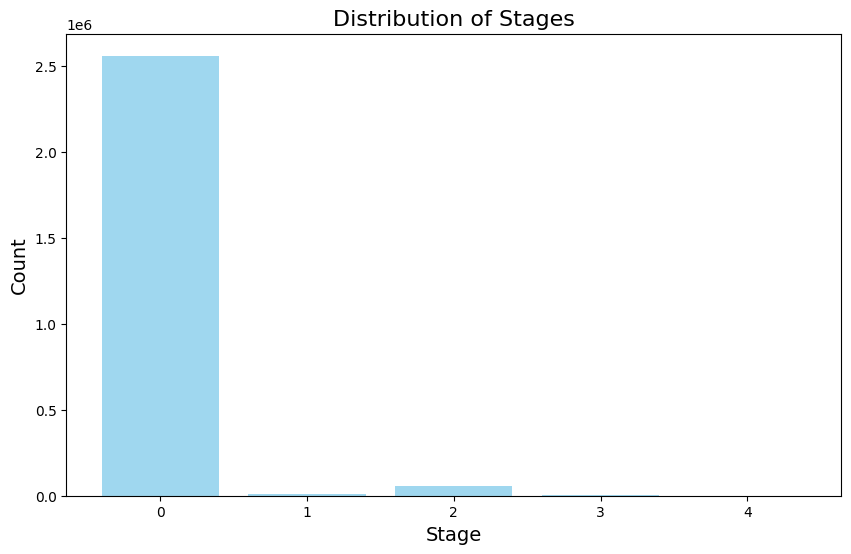

In [7]:
import matplotlib.pyplot as plt
# Đếm số lượng mẫu cho từng nhãn
stage_counts = df['Stage'].value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(stage_counts.index, stage_counts.values, color='skyblue', alpha=0.8)

# Thêm nhãn, tiêu đề và lưới
plt.title('Distribution of Stages', fontsize=16)
plt.xlabel('Stage', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(ticks=stage_counts.index, labels=[
    'Benign',
    'Reconnaissance',
    'Establish Foothold',
    'Lateral Movement',
    'Data Exfiltration',
    'Cover up'
], rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [8]:
from sklearn.utils import resample
import pandas as pd

# Định nghĩa số lượng mẫu mong muốn cho từng nhãn
desired_samples = {
    0: 1000,
    1: 3000,
    2: 3000,
    3: 1000,
    4: 359,
    # 5: 359
}

# Chia dữ liệu thành từng nhãn và resample theo số lượng mong muốn
df_balanced = pd.concat([
    resample(
        df[df['Stage'] == stage],
        replace=False,  # Không thay thế
        n_samples=desired_samples[stage],  # Số lượng mẫu mong muốn
        random_state=42
    )
    for stage in desired_samples.keys()
])

# Kiểm tra kết quả
print(df_balanced['Stage'].value_counts())

Stage
1    3000
2    3000
0    1000
3    1000
4     359
Name: count, dtype: int64


In [9]:
df_balanced.to_csv('D:/code/gr1/clean_data/unraveled/unraveled.csv', index=False)
